# 03 — Preprocessing
### Dataset: FaceForensics++ (C23)
This notebook covers:
- Loading pre-built index splits from notebook 01
- Defining training and validation augmentation pipelines
- Building the Dataset class using MTCNN face crops
- Handling class imbalance via WeightedRandomSampler
- Creating DataLoaders for training, validation, and testing
- Sanity checks on batch shape and label balance

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path

print("All libraries imported successfully.")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

Mounted at /content/drive
All libraries imported successfully.
PyTorch version : 2.10.0+cu128
CUDA available  : True


In [2]:
# Reload project paths and constants to make this notebook fully self-contained
PROJECT_ROOT = Path("/content/drive/MyDrive/deepfake_binary_project")

PROC_ROOT  = PROJECT_ROOT / "processed"
INDEX_DIR  = PROJECT_ROOT / "index"

FFPP_FACES_ROOT = PROC_ROOT / "ffpp_face_crops_224"

SEED       = 42
NUM_FRAMES = 16
IMG_SIZE   = 224
BATCH_SIZE = 8
NUM_WORKERS = 2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)

print(f"Device         : {device} ({torch.cuda.get_device_name(0)})")
print(f"Frames/video   : {NUM_FRAMES}")
print(f"Image size     : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Face crops root: {FFPP_FACES_ROOT}")

Device         : cuda (Tesla T4)
Frames/video   : 16
Image size     : 224x224
Batch size     : 8
Face crops root: /content/drive/MyDrive/deepfake_binary_project/processed/ffpp_face_crops_224


In [3]:
# Load pre-built split index files generated in notebook 01
train_df = pd.read_csv(INDEX_DIR / "ffpp_train.csv")
val_df   = pd.read_csv(INDEX_DIR / "ffpp_val.csv")
test_df  = pd.read_csv(INDEX_DIR / "ffpp_test.csv")

print("Split index files loaded successfully.")
print(f"\n  Train : {len(train_df)} videos  (real: {(train_df.binary_target==0).sum()} | fake: {(train_df.binary_target==1).sum()})")
print(f"  Val   : {len(val_df)} videos  (real: {(val_df.binary_target==0).sum()} | fake: {(val_df.binary_target==1).sum()})")
print(f"  Test  : {len(test_df)} videos  (real: {(test_df.binary_target==0).sum()} | fake: {(test_df.binary_target==1).sum()})")

Split index files loaded successfully.

  Train : 4200 videos  (real: 700 | fake: 3500)
  Val   : 900 videos  (real: 150 | fake: 750)
  Test  : 900 videos  (real: 150 | fake: 750)


## Part 1 — Augmentation Pipelines
Training augmentations introduce controlled variability to improve generalisation.
Validation and test transforms apply normalisation only to ensure consistent evaluation.

In [4]:
train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomRotation(degrees=10),
    T.RandomGrayscale(p=0.02),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.3),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Augmentation pipelines defined.")
print("\nTraining transforms:")
for t in train_transform.transforms:
    print(f"  {t.__class__.__name__}")
print("\nValidation/Test transforms:")
for t in val_transform.transforms:
    print(f"  {t.__class__.__name__}")

Augmentation pipelines defined.

Training transforms:
  ToPILImage
  RandomHorizontalFlip
  ColorJitter
  RandomRotation
  RandomGrayscale
  RandomApply
  ToTensor
  Normalize

Validation/Test transforms:
  ToPILImage
  ToTensor
  Normalize


## Part 2 — Dataset Class

In [5]:
class DeepfakeDataset(Dataset):
    """
    PyTorch Dataset for binary deepfake detection.
    Loads pre-extracted MTCNN face crops and applies the specified transform.
    Returns a tensor of shape (T, C, H, W) and a binary label.
    """

    def __init__(self, df, faces_root, transform=None, num_frames=NUM_FRAMES):
        self.df         = df.reset_index(drop=True)
        self.faces_root = Path(faces_root)
        self.transform  = transform
        self.num_frames = num_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        vid_stem = Path(row["path"]).stem
        label    = int(row["binary_target"])
        frame_dir = self.faces_root / row["binary_label"] / vid_stem

        frames = []
        for i in range(self.num_frames):
            img = cv2.imread(str(frame_dir / f"frame_{i:02d}.jpg"))
            if img is None:
                img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if self.transform:
                img = self.transform(img)
            else:
                img = T.Compose([T.ToPILImage(), T.ToTensor()])(img)

            frames.append(img)

        return torch.stack(frames), torch.tensor(label, dtype=torch.long)

print("DeepfakeDataset class defined.")

DeepfakeDataset class defined.


## Part 3 — DataLoaders & Class Imbalance Handling
WeightedRandomSampler is used to compensate for the 1:5 real-to-fake imbalance
in the training set, ensuring each batch contains a balanced mix of both classes.

In [6]:
train_dataset = DeepfakeDataset(train_df, FFPP_FACES_ROOT, transform=train_transform)
val_dataset   = DeepfakeDataset(val_df,   FFPP_FACES_ROOT, transform=val_transform)
test_dataset  = DeepfakeDataset(test_df,  FFPP_FACES_ROOT, transform=val_transform)

# Assign per-sample weights inversely proportional to class frequency
targets = train_df["binary_target"].values
counts  = np.bincount(targets)
weights = 1.0 / counts[targets]

sampler = WeightedRandomSampler(
    weights     = torch.tensor(weights, dtype=torch.float),
    num_samples = len(weights),
    replacement = True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS,
                          pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=NUM_WORKERS,
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=NUM_WORKERS,
                          pin_memory=True)

print(f"Train dataset  : {len(train_dataset)} videos")
print(f"Val dataset    : {len(val_dataset)} videos")
print(f"Test dataset   : {len(test_dataset)} videos")
print(f"\nClass weights  : real={weights[targets==0][0]:.4f} | fake={weights[targets==1][0]:.4f}")
print(f"Sampler        : WeightedRandomSampler (replacement=True)")

Train dataset  : 4200 videos
Val dataset    : 900 videos
Test dataset   : 900 videos

Class weights  : real=0.0014 | fake=0.0003
Sampler        : WeightedRandomSampler (replacement=True)


In [7]:
frames_batch, labels_batch = next(iter(train_loader))

print("Batch sanity check:")
print(f"  Frames shape : {frames_batch.shape}  (B, T, C, H, W)")
print(f"  Labels shape : {labels_batch.shape}")
print(f"  Label values : {labels_batch.tolist()}")
print(f"\n  Real in batch : {(labels_batch == 0).sum().item()}")
print(f"  Fake in batch : {(labels_batch == 1).sum().item()}")
print(f"\n  Pixel min : {frames_batch.min():.4f}")
print(f"  Pixel max : {frames_batch.max():.4f}")

Batch sanity check:
  Frames shape : torch.Size([8, 16, 3, 224, 224])  (B, T, C, H, W)
  Labels shape : torch.Size([8])
  Label values : [0, 0, 0, 1, 0, 1, 1, 0]

  Real in batch : 5
  Fake in batch : 3

  Pixel min : -2.1179
  Pixel max : 2.6400


## Part 4 — Visual Verification

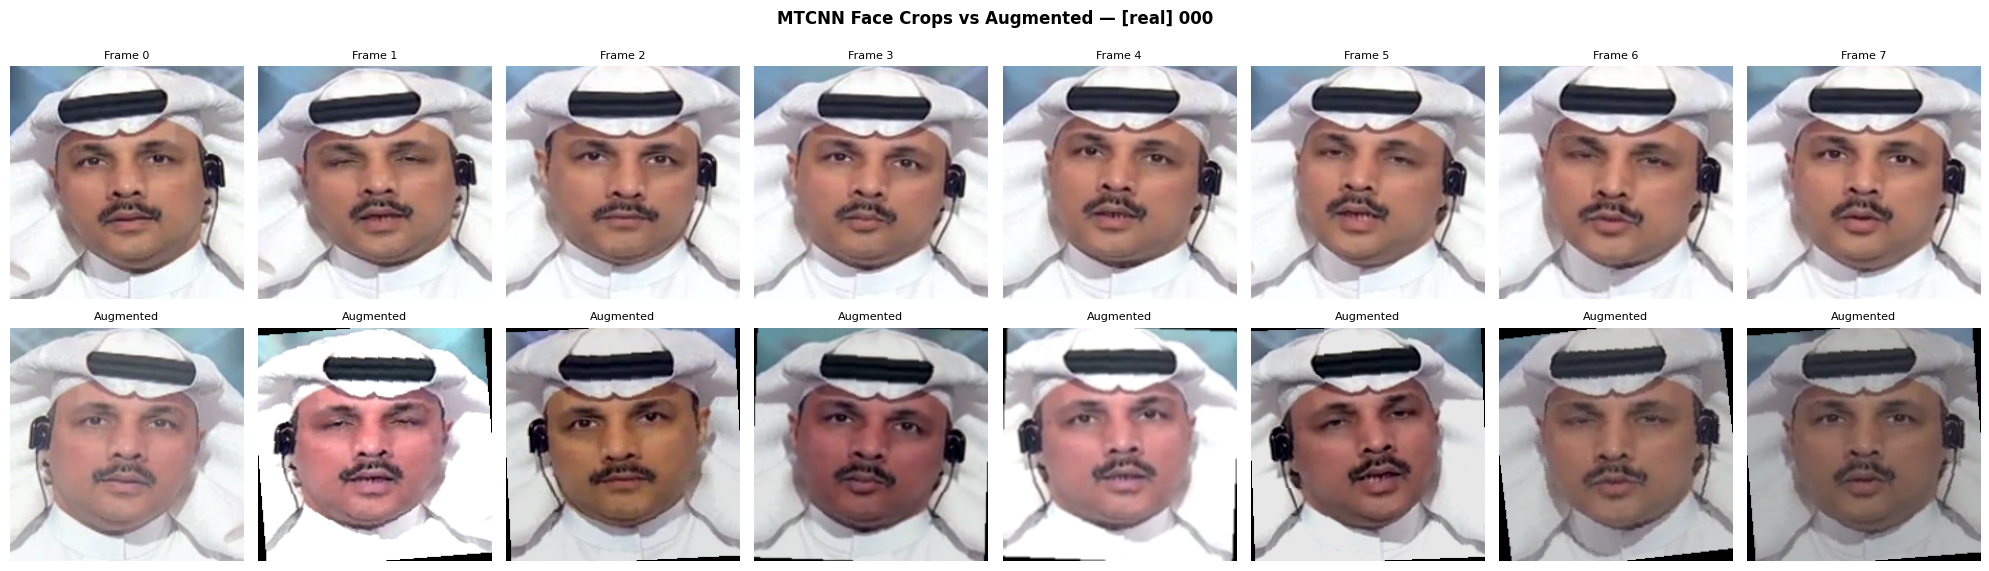

In [8]:
mean_arr = np.array(IMAGENET_MEAN, dtype=np.float32)
std_arr  = np.array(IMAGENET_STD,  dtype=np.float32)

def denormalize(tensor):
    """Reverse ImageNet normalization for visualization."""
    img = tensor.permute(1, 2, 0).numpy()
    img = np.clip(img * std_arr + mean_arr, 0, 1)
    return img

# Sample one video from the training set
sample_idx  = 0
vid_row     = train_df.iloc[sample_idx]
vid_stem    = Path(vid_row["path"]).stem
frame_dir   = FFPP_FACES_ROOT / vid_row["binary_label"] / vid_stem

fig, axes = plt.subplots(2, 8, figsize=(20, 6))

for i in range(8):
    raw_img = cv2.imread(str(frame_dir / f"frame_{i:02d}.jpg"))
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

    # Top row — original MTCNN crop
    axes[0, i].imshow(raw_img)
    axes[0, i].set_title(f"Frame {i}", fontsize=8)
    axes[0, i].axis("off")

    # Bottom row — after augmentation
    aug_img = train_transform(raw_img)
    axes[1, i].imshow(denormalize(aug_img))
    axes[1, i].set_title(f"Augmented", fontsize=8)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Augmented", fontsize=10)

plt.suptitle(f"MTCNN Face Crops vs Augmented — [{vid_row['binary_label']}] {vid_stem}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "eda_plots" / "12_augmentation_preview.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [9]:
print("=" * 55)
print("PREPROCESSING SUMMARY")
print("=" * 55)

print("\nFace Crops")
print(f"  Detector       : MTCNN")
print(f"  Frames/video   : {NUM_FRAMES}")
print(f"  Output size    : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Face margin    : 30%")

print("\nAugmentation Pipeline (Training)")
print(f"  RandomHorizontalFlip  : p=0.5")
print(f"  ColorJitter           : brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05")
print(f"  RandomRotation        : degrees=10")
print(f"  RandomGrayscale       : p=0.02")
print(f"  GaussianBlur          : p=0.3, sigma=(0.1, 1.5)")
print(f"  Normalize             : ImageNet mean/std")

print("\nClass Imbalance Handling")
print(f"  Strategy       : WeightedRandomSampler")
print(f"  Real weight    : {weights[targets==0][0]:.4f}")
print(f"  Fake weight    : {weights[targets==1][0]:.4f}")

print("\nDataLoaders")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Train batches  : {len(train_loader)}")
print(f"  Val batches    : {len(val_loader)}")
print(f"  Test batches   : {len(test_loader)}")
print(f"  Batch shape    : (8, 16, 3, 224, 224)  [B, T, C, H, W]")
print("=" * 55)

PREPROCESSING SUMMARY

Face Crops
  Detector       : MTCNN
  Frames/video   : 16
  Output size    : 224x224
  Face margin    : 30%

Augmentation Pipeline (Training)
  RandomHorizontalFlip  : p=0.5
  ColorJitter           : brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05
  RandomRotation        : degrees=10
  RandomGrayscale       : p=0.02
  GaussianBlur          : p=0.3, sigma=(0.1, 1.5)
  Normalize             : ImageNet mean/std

Class Imbalance Handling
  Strategy       : WeightedRandomSampler
  Real weight    : 0.0014
  Fake weight    : 0.0003

DataLoaders
  Batch size     : 8
  Train batches  : 525
  Val batches    : 113
  Test batches   : 113
  Batch shape    : (8, 16, 3, 224, 224)  [B, T, C, H, W]
